# Kronos — VNINDEX Candlestick Forecasting

Apply the **Kronos** foundation model ([shiyu-coder/Kronos](https://github.com/shiyu-coder/Kronos)) to forecast VNINDEX OHLC candlesticks.

| Step | Description |
|------|-------------|
| **1** | Load VNINDEX OHLCV from Delta Lake / HDF5 cache |
| **2** | Install & set up Kronos (clone repo + install deps) |
| **3** | Load pretrained model from HuggingFace |
| **4** | Run multi-path forecast on the last N bars |
| **5** | Visualise actual vs predicted candlesticks |
| **6** | Evaluate walk-forward accuracy |


## 0. Setup — Install Kronos

In [53]:
import subprocess, sys, os, pathlib

KRONOS_DIR = pathlib.Path('../vendor/Kronos')

if not KRONOS_DIR.exists():
    print('Cloning Kronos …')
    KRONOS_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ['git', 'clone', 'https://github.com/shiyu-coder/Kronos.git', str(KRONOS_DIR)],
        check=True,
    )
    print('Installing requirements …')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-r', str(KRONOS_DIR / 'requirements.txt'), '-q'],
        check=True,
    )
else:
    print(f'Kronos already cloned at {KRONOS_DIR}')

# Add Kronos to path so `from model import ...` works
kronos_path = str(KRONOS_DIR.resolve())
if kronos_path not in sys.path:
    sys.path.insert(0, kronos_path)

print('Kronos path ready')

Kronos already cloned at ../vendor/Kronos
Kronos path ready


## 1. Imports

In [54]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#333355',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'legend.facecolor': '#2a2a4e',
    'legend.labelcolor':'white',
})

SYMBOL    = 'VNINDEX'
ANNUALISE = 252

print('Imports OK')

Imports OK


## 2. Load Data

In [55]:
REMOTE_HOST = 'https://minio.phuchuynh.xyz'
LOCAL_FILE  = 'stocks_data_latest.h5'

def load_from_delta() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    start_date = pd.Timestamp.now() - pd.DateOffset(years=10)
    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', '=', SYMBOL)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol']).unstack(level=1)
    return raw


if os.path.exists(LOCAL_FILE):
    print(f'Loading from local HDF5: {LOCAL_FILE}')
    with pd.HDFStore(LOCAL_FILE, mode='r') as store:
        df_all = store['stocks']
else:
    print('HDF5 not found — loading from Delta Lake …')
    df_all = load_from_delta()
    with pd.HDFStore(LOCAL_FILE, mode='w') as store:
        store.put('stocks', df_all)

# Extract VNINDEX OHLCV
vn = pd.DataFrame({
    'open':   df_all['open'][SYMBOL],
    'high':   df_all['high'][SYMBOL],
    'low':    df_all['low'][SYMBOL],
    'close':  df_all['close'][SYMBOL],
    'volume': df_all['volume'][SYMBOL],
}).dropna()

vn.index = pd.to_datetime(vn.index)
vn = vn.sort_index()

print(f'Loaded {len(vn):,} bars  |  {vn.index[0].date()} → {vn.index[-1].date()}')
vn.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Loaded 2,500 bars  |  2016-04-04 → 2026-04-03


,open,high,low,close,volume
date,,,,,
2026-04-01,1713.920044,1715.209961,1700.180054,1705.739990,905114368.0
2026-04-02,1706.150024,1706.150024,1684.469971,1695.130005,823926592.0
2026-04-03,1700.140015,1713.949951,1679.790039,1684.089966,726054464.0


## 3. Visualise Historical OHLCV

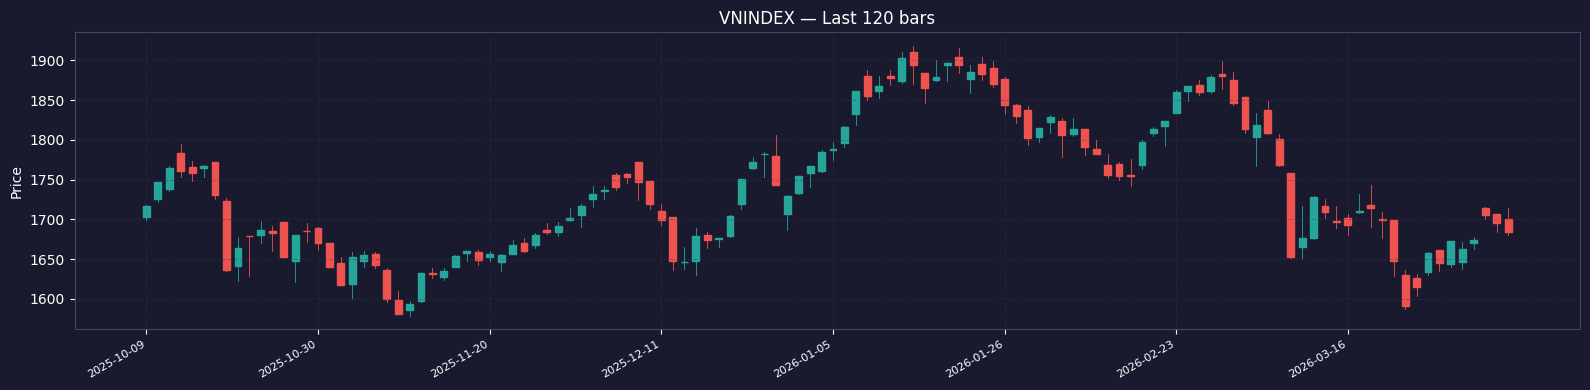

In [56]:
def plot_candlestick(df: pd.DataFrame, title: str = 'VNINDEX', ax=None, alpha: float = 1.0):
    """Minimal candlestick chart on a matplotlib axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))
    
    for i, (ts, row) in enumerate(df.iterrows()):
        o, h, l, c = row['open'], row['high'], row['low'], row['close']
        color = '#26a69a' if c >= o else '#ef5350'  # teal = bull, red = bear
        ax.plot([i, i], [l, h], color=color, lw=0.6, alpha=alpha)
        ax.add_patch(mpatches.FancyBboxPatch(
            (i - 0.3, min(o, c)), 0.6, abs(c - o),
            boxstyle='square,pad=0', color=color, alpha=alpha
        ))
    
    n = len(df)
    step = max(1, n // 8)
    ax.set_xticks(range(0, n, step))
    ax.set_xticklabels([df.index[i].strftime('%Y-%m-%d') for i in range(0, n, step)],
                       rotation=30, ha='right', fontsize=8)
    ax.set_title(title, color='white')
    ax.set_ylabel('Price', color='white')
    ax.grid(True)
    return ax


# Show last 120 bars of history
fig, ax = plt.subplots(figsize=(16, 4))
plot_candlestick(vn.tail(120), title=f'{SYMBOL} — Last 120 bars', ax=ax)
plt.tight_layout()
plt.show()

## 4. Load Kronos Model

In [ ]:
from model import Kronos, KronosTokenizer, KronosPredictor

# Model options:
#   NeoQuasar/Kronos-mini  — 4.1M params, 2048 ctx length (fastest)
#   NeoQuasar/Kronos-small — 24.7M params,  512 ctx length (balanced)
#   NeoQuasar/Kronos-base  — 102.3M params, 512 ctx length (most accurate)
MODEL_ID      = 'NeoQuasar/Kronos-base'
TOKENIZER_ID  = 'NeoQuasar/Kronos-Tokenizer-base'
MAX_CONTEXT   = 512   # bars of history fed to the model

print(f'Loading tokenizer: {TOKENIZER_ID}')
tokenizer = KronosTokenizer.from_pretrained(TOKENIZER_ID)

print(f'Loading model: {MODEL_ID}')
model = Kronos.from_pretrained(MODEL_ID)

predictor = KronosPredictor(model, tokenizer, max_context=MAX_CONTEXT)
print('Kronos ready')

Loading tokenizer: NeoQuasar/Kronos-Tokenizer-base
Loading model: NeoQuasar/Kronos-base


config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

## 5. Single-Shot Forecast

Use the last `MAX_CONTEXT` bars as context and forecast the next `PRED_LEN` trading days.

In [ ]:
PRED_LEN     = 30    # bars to forecast
SAMPLE_COUNT = 5     # stochastic paths
TEMPERATURE  = 1.0
TOP_P        = 0.9

# Context window: last MAX_CONTEXT bars
ctx = vn.tail(MAX_CONTEXT).copy()
# Include volume: if omitted, Kronos fills volume/amount with 0 → bogus vol/amount forecasts.
x_df        = ctx[['open', 'high', 'low', 'close', 'volume']]
x_timestamp = pd.Series(ctx.index, name="date")  # ensure it's a pd.Series

# Future timestamps: extend from last date with business-day frequency
last_date   = ctx.index[-1]
y_timestamp = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=PRED_LEN)
y_timestamp = pd.Series(y_timestamp, name="date")  # ensure it's a pd.Series

print(f'Context: {x_timestamp.iloc[0].date()} → {x_timestamp.iloc[-1].date()}  ({len(x_timestamp)} bars)')
print(f'Forecast: {y_timestamp.iloc[0].date()} → {y_timestamp.iloc[-1].date()}  ({PRED_LEN} bars)')
print(f'Generating {SAMPLE_COUNT} sample paths …')

pred_df = predictor.predict(
    df           = x_df,
    x_timestamp  = x_timestamp,
    y_timestamp  = y_timestamp,
    pred_len     = PRED_LEN,
    T            = TEMPERATURE,
    top_p        = TOP_P,
    sample_count = SAMPLE_COUNT,
)

print('Forecast done')
print(f'Output shape: {pred_df.shape}')
pred_df.head()

Context: 2024-03-14 → 2026-04-03  (512 bars)
Forecast: 2026-04-06 → 2026-05-15  (30 bars)
Generating 5 sample paths …


100%|██████████| 30/30 [00:01<00:00, 17.94it/s]

Forecast done
Output shape: (30, 6)


,open,high,low,close,volume,amount
date,,,,,,
2026-04-06,1692.701782,1733.433716,1686.223633,1721.800049,9.086335e+08,1.390172e+12
2026-04-07,1723.790894,1736.733643,1705.804932,1724.381104,8.831157e+08,1.336875e+12
2026-04-08,1732.512207,1742.747803,1703.226929,1711.711304,8.726598e+08,1.315899e+12
2026-04-09,1724.060059,1741.611816,1703.990479,1725.461914,1.031009e+09,1.625991e+12
2026-04-10,1730.512939,1757.890015,1708.257568,1739.481079,9.990997e+08,1.574203e+12


In [ ]:
if isinstance(pred_df.columns, pd.MultiIndex):
    # Multi-index: (sample_i, field)
    samples = {}
    for col in pred_df.columns.get_level_values(0).unique():
        samples[col] = pred_df[col]
    # median across samples for main prediction
    close_preds = pd.concat([pred_df[s]['close'] for s in samples], axis=1)
    close_med   = close_preds.median(axis=1)
    close_lo    = close_preds.min(axis=1)
    close_hi    = close_preds.max(axis=1)
    ohlc_med    = pred_df[list(samples.keys())[0]]  # first sample for candles
else:
    # Flat: single sample
    close_med = pred_df['close']
    close_lo  = close_med
    close_hi  = close_med
    ohlc_med  = pred_df

## 6. Visualise Forecast vs History

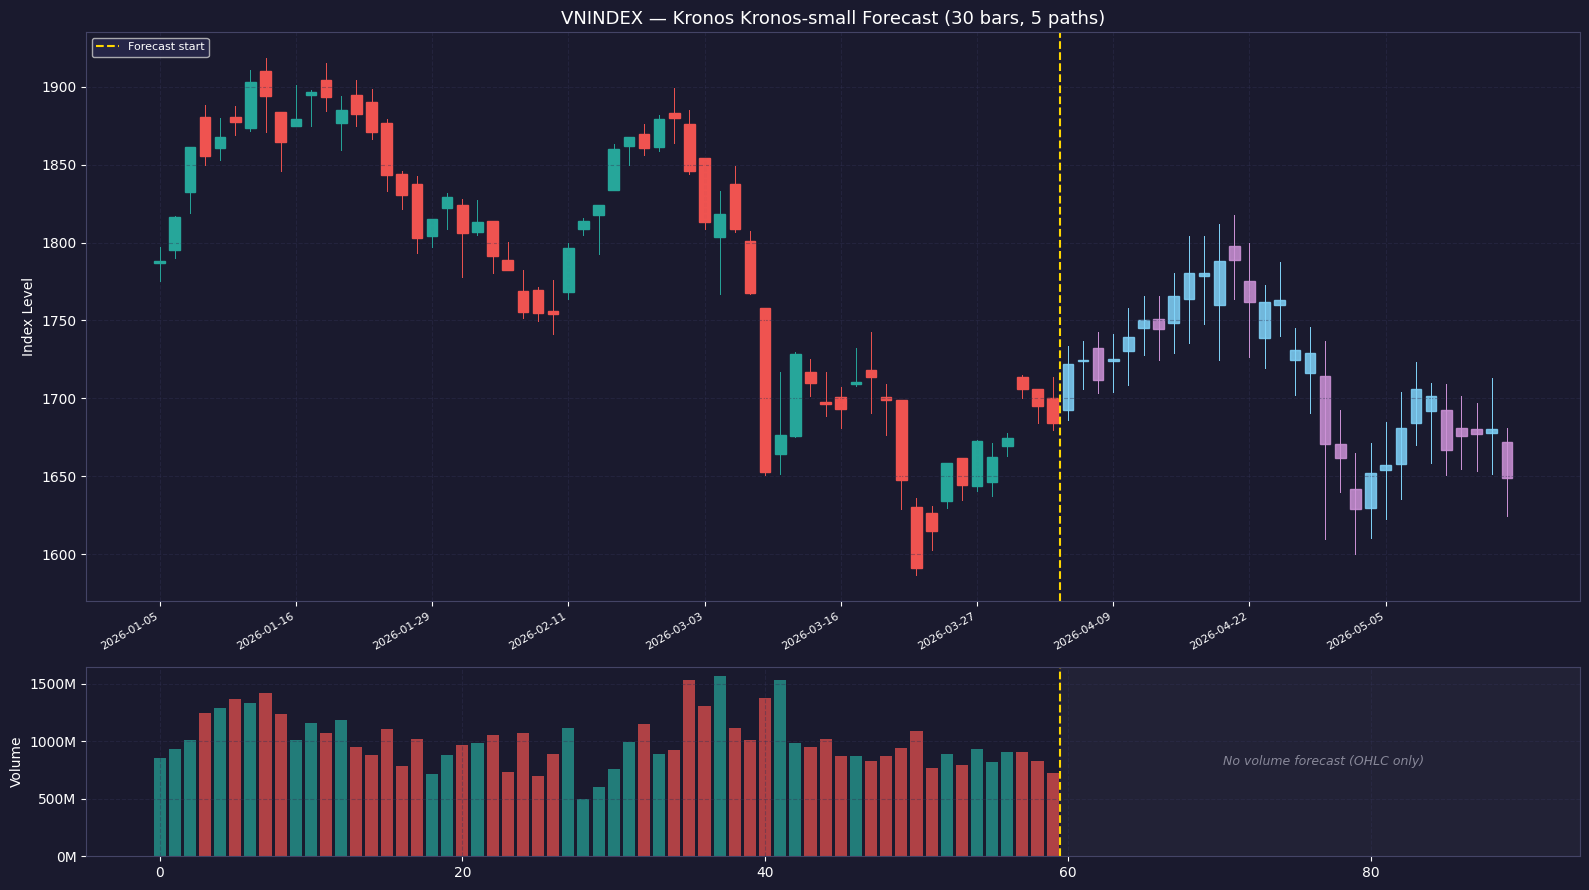

Chart saved → kronos_vnindex_forecast.png


In [ ]:
# ── parse multi-sample output ────────────────────────────────────────────────
if isinstance(pred_df.columns, pd.MultiIndex):
    samples = {}
    for col in pred_df.columns.get_level_values(0).unique():
        samples[col] = pred_df[col]
    close_preds = pd.concat([pred_df[s]['close'] for s in samples], axis=1)
    close_med   = close_preds.median(axis=1)
    close_lo    = close_preds.min(axis=1)
    close_hi    = close_preds.max(axis=1)
    ohlc_med    = pred_df[list(samples.keys())[0]]
else:
    close_med = pred_df['close']
    close_lo  = close_med
    close_hi  = close_med
    ohlc_med  = pred_df


# ── plot ─────────────────────────────────────────────────────────────────────
HIST_BARS = 60

fig, axes = plt.subplots(2, 1, figsize=(16, 9),
                         gridspec_kw={'height_ratios': [3, 1]})
ax_price, ax_vol = axes

hist = vn.tail(HIST_BARS)

# — history candlesticks —
for i, (ts, row) in enumerate(hist.iterrows()):
    o, h, l, c = row['open'], row['high'], row['low'], row['close']
    color = '#26a69a' if c >= o else '#ef5350'
    ax_price.plot([i, i], [l, h], color=color, lw=0.7)
    ax_price.add_patch(mpatches.FancyBboxPatch(
        (i - 0.35, min(o, c)), 0.7, abs(c - o),
        boxstyle='square,pad=0', color=color
    ))

# — forecast region —
offset = HIST_BARS
ax_price.axvline(offset - 0.5, color='#ffd700', lw=1.5, ls='--', label='Forecast start')

if isinstance(pred_df.columns, pd.MultiIndex):
    for s in samples:
        sample_close = pred_df[s]['close'].values
        ax_price.plot(
            range(offset, offset + len(sample_close)),
            sample_close,
            color='#90caf9', lw=0.6, alpha=0.4,
        )

for i, (ts, row) in enumerate(ohlc_med.iterrows()):
    o = row.get('open', close_med.iloc[i])
    h = row.get('high', close_med.iloc[i])
    l = row.get('low',  close_med.iloc[i])
    c = row.get('close', close_med.iloc[i])
    color = '#81d4fa' if c >= o else '#ce93d8'
    ax_price.plot([offset + i, offset + i], [l, h], color=color, lw=0.7)
    ax_price.add_patch(mpatches.FancyBboxPatch(
        (offset + i - 0.35, min(o, c)), 0.7, max(abs(c - o), 1),
        boxstyle='square,pad=0', color=color, alpha=0.85
    ))

if not close_lo.equals(close_hi):
    ax_price.fill_between(
        range(offset, offset + len(close_lo)),
        close_lo.values, close_hi.values,
        color='#90caf9', alpha=0.15, label='Forecast range'
    )

all_dates = list(hist.index) + list(y_timestamp)
total_bars = len(all_dates)
tick_step  = max(1, total_bars // 10)
ax_price.set_xticks(range(0, total_bars, tick_step))
ax_price.set_xticklabels(
    [all_dates[i].strftime('%Y-%m-%d') for i in range(0, total_bars, tick_step)],
    rotation=30, ha='right', fontsize=8
)
ax_price.set_title(f'{SYMBOL} — Kronos {MODEL_ID.split("/")[1]} Forecast ({PRED_LEN} bars, {SAMPLE_COUNT} paths)',
                   color='white', fontsize=13)
ax_price.set_ylabel('Index Level')
ax_price.legend(loc='upper left', fontsize=8)
ax_price.grid(True)

# — volume bar (history only; Kronos forecasts OHLC, not volume) —
vol_colors = ['#26a69a' if vn['close'].iloc[-HIST_BARS + i] >= vn['open'].iloc[-HIST_BARS + i]
               else '#ef5350' for i in range(HIST_BARS)]
ax_vol.bar(range(HIST_BARS), hist['volume'].values, color=vol_colors, alpha=0.7, width=0.8)

xlim = ax_price.get_xlim()
ax_vol.set_xlim(xlim)

# Shade forecast region and annotate — no volume output from Kronos
ax_vol.axvline(offset - 0.5, color='#ffd700', lw=1.5, ls='--')
ax_vol.axvspan(offset - 0.5, xlim[1], color='#ffffff', alpha=0.04)
ax_vol.text(
    offset + (xlim[1] - offset) / 2, 0.5,
    'No volume forecast (OHLC only)',
    transform=ax_vol.get_xaxis_transform(),
    ha='center', va='center', fontsize=9,
    color='#888899', style='italic',
)

ax_vol.set_ylabel('Volume')
ax_vol.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax_vol.grid(True)

plt.tight_layout()
plt.savefig('kronos_vnindex_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → kronos_vnindex_forecast.png')

## 7. Walk-Forward Evaluation

Backtest predictive accuracy: for each evaluation window, feed `MAX_CONTEXT` bars as context, forecast `PRED_LEN` bars, then compare predicted close vs actual close.

Metrics: **MAE**, **MAPE**, **Directional Accuracy**.

In [ ]:
EVAL_WINDOWS = 5     # number of walk-forward windows to evaluate
EVAL_PRED    = 20    # forecast horizon per window
EVAL_CTX     = 200   # context bars per window

results = []
total_bars = len(vn)

# Space windows evenly across the last 40% of data
eval_start = int(total_bars * 0.6)
step       = (total_bars - eval_start - EVAL_CTX - EVAL_PRED) // max(EVAL_WINDOWS - 1, 1)

for w in range(EVAL_WINDOWS):
    ctx_end   = eval_start + EVAL_CTX + w * step
    if ctx_end + EVAL_PRED > total_bars:
        break

    ctx_df    = vn.iloc[ctx_end - EVAL_CTX : ctx_end]
    actual_df = vn.iloc[ctx_end : ctx_end + EVAL_PRED]

    x_df        = ctx_df[['open', 'high', 'low', 'close', 'volume']]
    x_ts        = pd.Series(ctx_df.index, name='date')
    y_ts        = pd.Series(actual_df.index, name='date')

    # Correct handling of DatetimeIndex/Timestamp for safe date display (avoid .dt!)
    def _get_date(idx, pos):
        # idx: DatetimeIndex, Index or Series of Timestamps
        val = idx.iloc[pos] if hasattr(idx, 'iloc') else idx[pos]
        if isinstance(val, pd.Timestamp):
            return val.date()
        return pd.to_datetime(val).date() if not hasattr(val, "date") else val.date()

    print(f'Window {w+1}/{EVAL_WINDOWS}: ctx={_get_date(x_ts, 0)}→{_get_date(x_ts, -1)}, '
          f'forecast={_get_date(y_ts, 0)}→{_get_date(y_ts, -1)}')

    # Kronos expects index-like objects for x_timestamp/y_timestamp,
    # but its feature extractor wrongly uses .dt on DatetimeIndex.
    # Workaround: pass as Series, which has a .dt accessor and is accepted by Kronos.
    pred = predictor.predict(
        df           = x_df,
        x_timestamp  = x_ts,
        y_timestamp  = y_ts,
        pred_len     = EVAL_PRED,
        T            = TEMPERATURE,
        top_p        = TOP_P,
        sample_count = 1,
    )

    # Normalise to flat dataframe if multi-index
    if isinstance(pred.columns, pd.MultiIndex):
        pred_flat = pred[pred.columns.get_level_values(0).unique()[0]]
    else:
        pred_flat = pred

    pred_close   = pred_flat['close'].values
    actual_close = actual_df['close'].values[:len(pred_close)]

    mae  = np.mean(np.abs(pred_close - actual_close))
    mape = np.mean(np.abs((pred_close - actual_close) / actual_close)) * 100
    # Directional accuracy: does predicted direction match actual?
    last_close  = ctx_df['close'].iloc[-1]
    pred_dir    = np.sign(pred_close - np.concatenate([[last_close], pred_close[:-1]]))
    actual_dir  = np.sign(actual_close - np.concatenate([[last_close], actual_close[:-1]]))
    dir_acc     = (pred_dir == actual_dir).mean() * 100

    results.append({
        'window':    w + 1,
        'from':      _get_date(y_ts, 0),
        'to':        _get_date(y_ts, -1),
        'MAE':       round(mae, 2),
        'MAPE (%)':  round(mape, 2),
        'Dir Acc (%)': round(dir_acc, 1),
    })

eval_df = pd.DataFrame(results)
print('\nWalk-forward evaluation results:')
eval_df

Window 1/5: ctx=2022-03-31→2023-01-12, forecast=2023-01-13→2023-02-16


100%|██████████| 20/20 [00:00<00:00, 24.35it/s]


Window 2/5: ctx=2023-01-06→2023-10-26, forecast=2023-10-27→2023-11-23


100%|██████████| 20/20 [00:00<00:00, 37.11it/s]


Window 3/5: ctx=2023-10-20→2024-08-08, forecast=2024-08-09→2024-09-09


...

100%|██████████| 20/20 [00:00<00:00, 35.57it/s]


Window 5/5: ctx=2025-05-20→2026-03-06, forecast=2026-03-09→2026-04-03


100%|██████████| 20/20 [00:00<00:00, 37.71it/s]


Walk-forward evaluation results:


,window,from,to,MAE,MAPE (%),Dir Acc (%)
0,1,2023-01-13,2023-02-16,62.24,5.73,35.0
1,2,2023-10-27,2023-11-23,24.44,2.23,50.0
2,3,2024-08-09,2024-09-09,82.46,6.47,45.0
3,4,2025-05-27,2025-06-23,41.39,3.08,60.0
4,5,2026-03-09,2026-04-03,111.86,6.73,60.0


=== Walk-Forward Summary ===
Mean MAE       : 64.48
Mean MAPE      : 4.85%
Mean Dir Acc   : 50.0%
Baseline Dir Acc (random): 50.0%


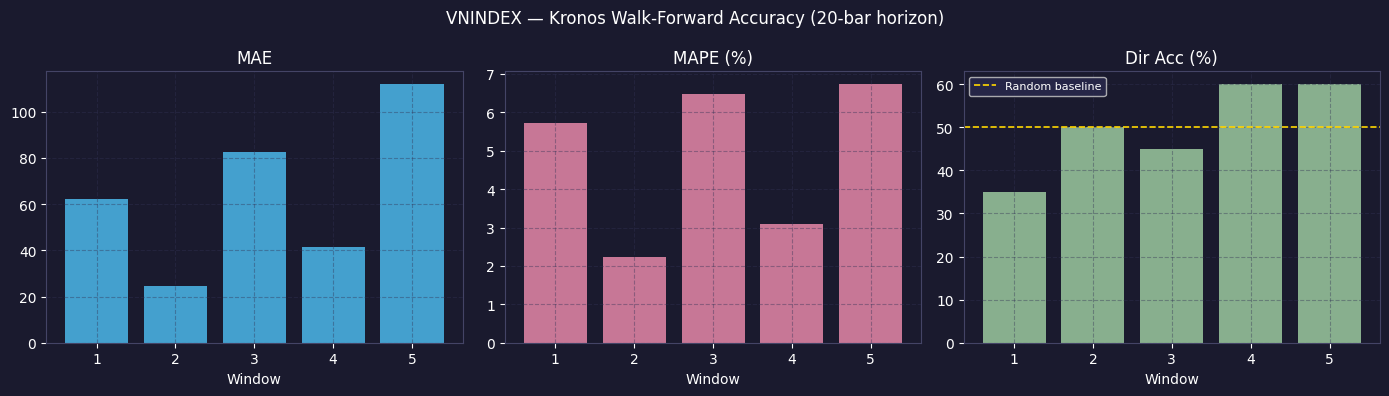

In [ ]:
# ── summary stats ─────────────────────────────────────────────────────────────
print('=== Walk-Forward Summary ===')
print(f"Mean MAE       : {eval_df['MAE'].mean():.2f}")
print(f"Mean MAPE      : {eval_df['MAPE (%)'].mean():.2f}%")
print(f"Mean Dir Acc   : {eval_df['Dir Acc (%)'].mean():.1f}%")
print(f"Baseline Dir Acc (random): 50.0%")

# Plot MAPE across windows
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes,
                           ['MAE', 'MAPE (%)', 'Dir Acc (%)'],
                           ['#4fc3f7', '#f48fb1', '#a5d6a7']):
    ax.bar(eval_df['window'], eval_df[col], color=color, alpha=0.8)
    ax.set_xlabel('Window')
    ax.set_title(col)
    ax.grid(True)
    if col == 'Dir Acc (%)':
        ax.axhline(50, color='#ffd700', ls='--', lw=1.2, label='Random baseline')
        ax.legend(fontsize=8)

fig.suptitle(f'{SYMBOL} — Kronos Walk-Forward Accuracy ({EVAL_PRED}-bar horizon)',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Multi-Sample Path Analysis

Generate many sample paths from the most recent context and plot the distribution of outcomes.

Generating 20 sample paths …


100%|██████████| 30/30 [00:06<00:00,  4.51it/s]

close_paths shape: (30, 1)  (bars × samples)


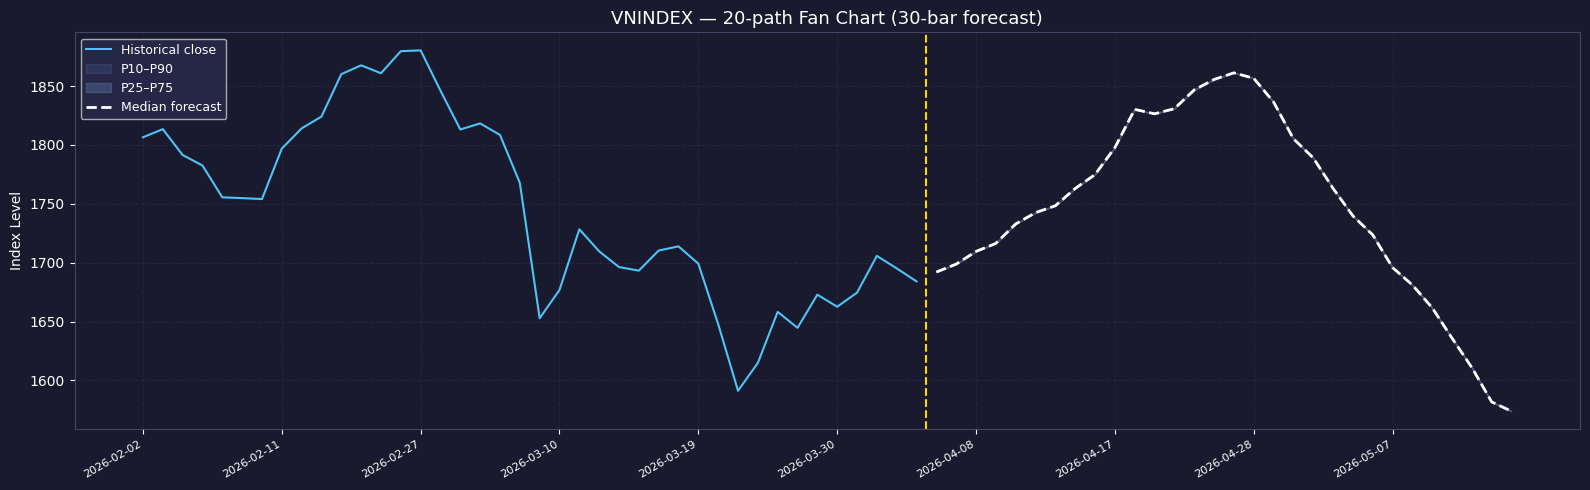

Fan chart saved → kronos_vnindex_fan.png


In [ ]:
N_PATHS = 20
PLOT_BARS = 30  # forecast horizon for this analysis

# Prepare recent context for prediction
ctx = vn.tail(MAX_CONTEXT).copy()
x_df = ctx[['open', 'high', 'low', 'close', 'volume']]
x_timestamp = pd.Series(ctx.index)
y_timestamp = pd.Series(
    pd.bdate_range(start=ctx.index[-1] + pd.Timedelta(days=1), periods=PLOT_BARS)
)

print(f'Generating {N_PATHS} sample paths …')
multi_pred = predictor.predict(
    df=x_df,
    x_timestamp=x_timestamp,
    y_timestamp=y_timestamp,
    pred_len=PLOT_BARS,
    T=TEMPERATURE,
    top_p=TOP_P,
    sample_count=N_PATHS,
)

# Extract forecast close price paths (bars × samples)
if isinstance(multi_pred.columns, pd.MultiIndex):
    sample_names = multi_pred.columns.get_level_values(0).unique()
    close_paths = np.stack(
        [multi_pred[s]['close'].values for s in sample_names], axis=1
    )
else:
    close_paths = multi_pred['close'].values[:, None]
print(f'close_paths shape: {close_paths.shape}  (bars × samples)')

# ── Fan chart ──────────────────────────────────────────────────
HIST_TAIL = 40
hist_close = vn['close'].tail(HIST_TAIL).values
hist_dates = list(vn.index[-HIST_TAIL:])

fig, ax = plt.subplots(figsize=(16, 5))

# Plot historical close
ax.plot(
    range(HIST_TAIL),
    hist_close,
    color='#4fc3f7',
    lw=1.5,
    label='Historical close'
)

# Vertical forecast boundary
ax.axvline(HIST_TAIL - 0.5, color='#ffd700', lw=1.5, ls='--')

x_fut = range(HIST_TAIL, HIST_TAIL + PLOT_BARS)

# Plot all sample paths
for j in range(close_paths.shape[1]):
    ax.plot(x_fut, close_paths[:, j], color='#90caf9', lw=0.5, alpha=0.3)

# Percentiles of sample paths
percentiles = np.percentile(close_paths, [10, 25, 50, 75, 90], axis=1)
p10, p25, p50, p75, p90 = percentiles

ax.fill_between(x_fut, p10, p90, color='#90caf9', alpha=0.10, label='P10–P90')
ax.fill_between(x_fut, p25, p75, color='#90caf9', alpha=0.20, label='P25–P75')
ax.plot(x_fut, p50, color='#ffffff', lw=2.0, ls='--', label='Median forecast')

# x-axis: mix of historical and future dates
all_dates = hist_dates + list(y_timestamp)
total_pts = len(all_dates)
tick_step = max(1, total_pts // 10)
ax.set_xticks(range(0, total_pts, tick_step))
ax.set_xticklabels(
    [
        all_dates[i].strftime('%Y-%m-%d')
        if hasattr(all_dates[i], 'strftime')
        else pd.Timestamp(all_dates[i]).strftime('%Y-%m-%d')
        for i in range(0, total_pts, tick_step)
    ],
    rotation=30,
    ha='right',
    fontsize=8,
)

ax.set_title(
    f'{SYMBOL} — {N_PATHS}-path Fan Chart ({PLOT_BARS}-bar forecast)', fontsize=13
)
ax.set_ylabel('Index Level')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('kronos_vnindex_fan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fan chart saved → kronos_vnindex_fan.png')

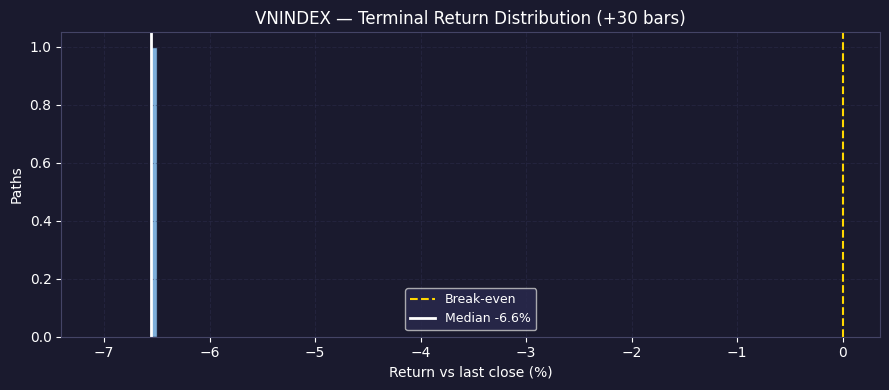

Last close   : 1,684.09
Median target: 1,573.75  (-6.6%)
Bull paths   : 0%  |  Bear paths: 100%
P10 / P90    : -6.6% / -6.6%


In [ ]:
# ── Terminal distribution ─────────────────────────────────────────────────────
last_actual = vn['close'].iloc[-1]
terminal    = close_paths[-1, :]  # end-of-forecast price per path
ret_pct     = (terminal / last_actual - 1) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ret_pct, bins=20, color='#90caf9', edgecolor='#1a1a2e', alpha=0.85)
ax.axvline(0,                color='#ffd700', lw=1.5, ls='--', label='Break-even')
ax.axvline(np.median(ret_pct), color='white', lw=2.0, ls='-',  label=f'Median {np.median(ret_pct):.1f}%')
ax.set_xlabel('Return vs last close (%)')
ax.set_ylabel('Paths')
ax.set_title(f'{SYMBOL} — Terminal Return Distribution (+{PLOT_BARS} bars)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

bull_pct = (ret_pct > 0).mean() * 100
print(f'Last close   : {last_actual:,.2f}')
print(f'Median target: {np.median(terminal):,.2f}  ({np.median(ret_pct):+.1f}%)')
print(f'Bull paths   : {bull_pct:.0f}%  |  Bear paths: {100-bull_pct:.0f}%')
print(f'P10 / P90    : {np.percentile(ret_pct,10):.1f}% / {np.percentile(ret_pct,90):.1f}%')